In [31]:
import seaborn as sns  
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
print(sns.get_dataset_names())
df=sns.load_dataset("car_crashes")
print(df.head())
df.info()

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']
   total  speeding  alcohol  not_distracted  no_previous  ins_premium  \
0   18.8     7.332    5.640          18.048       15.040       784.55   
1   18.1     7.421    4.525          16.290       17.014      1053.48   
2   18.6     6.510    5.208          15.624       17.856       899.47   
3   22.4     4.032    5.824          21.056       21.280       827.34   
4   12.0     4.200    3.360          10.920       10.680       878.41   

   ins_losses abbrev  
0      145.08     AL  
1      133.93     AK  
2      110.35     AZ  
3      142.39     AR  
4      165.63     CA  
<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 

The dataset explores automobile collisions per billion miles.
- First we explore the Relationship Between Speeding and Alcohol:
  The position of the dots tells you if these two behaviors go hand-in-hand.

  If you see a diagonal cluster, it indicates that states with a high rate of speeding also tend to have a high rate of alcohol-related fatal crashes.
  If a state has high speeding but cool color for total this indicates that speeding isnt really the cause of fatatlies in this state.

  We notice how the biggest and darkest dots (indicating laregest amount of accidents) are in states where speeding and drinking are both high.

  We also see that there is a positive correlation between drinking and speeding

  Note that the speeding and alchol dont always add up to the total as there are many other reasons for accidents.

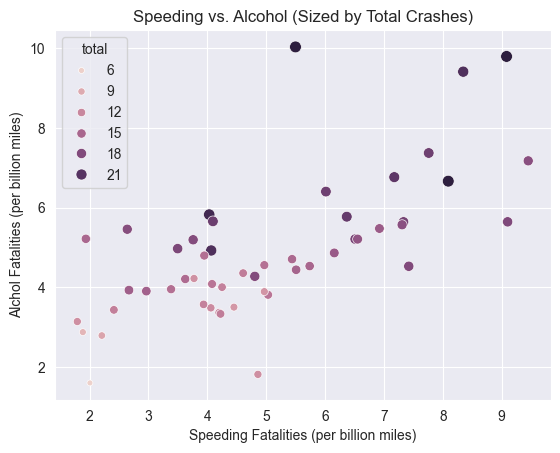

In [48]:
sns.set_style("darkgrid")
sns.scatterplot(data=df, x='speeding', y='alcohol', hue='total',size='total')
plt.title('Speeding vs. Alcohol (Sized by Total Crashes)')
plt.xlabel('Speeding Fatalities (per billion miles)')
plt.ylabel('Alchol Fatalities (per billion miles)')
plt.show()

- Secondally, we take a broder look on the data visualising the overall     nnumber of fatalities vs states.
  we first look at how many states are to be considered safe or dangerous.
  



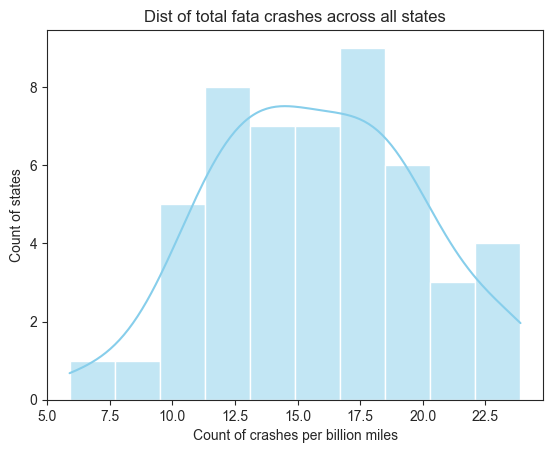

In [58]:
sns.histplot(data=df,x='total',bins=10, kde = True, color="skyblue")
sns.set_style("ticks")
plt.title('Dist of total fata crashes across all states')
plt.ylabel('Count of states')
plt.xlabel('Count of crashes per billion miles')
plt.show()

Now we try to get a rogue prediction of what the probability of a crash occuring for most states using ECDF plot.

what it shows is for a given count of total crash ex:15 on the axis, what is the percent of states that that has that number of crash or lower , meaning 0.6 of states in the 15 example.

We notice that a big spike occurs around the 13 carsh mark.

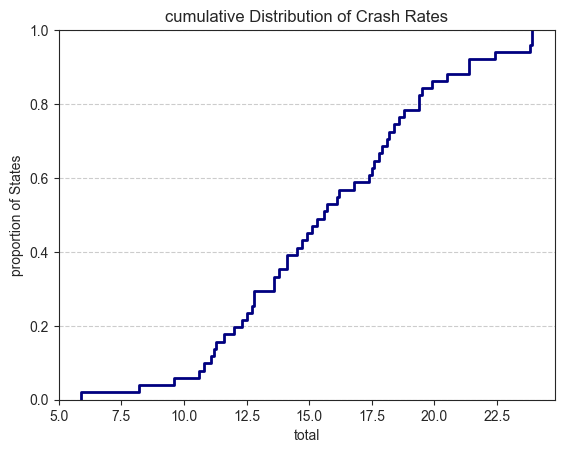

In [62]:
sns.ecdfplot(data=df, x='total', color="navy", linewidth=2)
plt.grid(axis='y', linestyle='--')
plt.title("cumulative Distribution of Crash Rates")
plt.ylabel("proportion of States")
plt.show()

Now we compare the indivisual states in terms of overall crashes looking for possible outliers using bar charts.

we will first make the figure size much bigger as to fit all 52 states, then put them on the y axis to have infinite vertical space to work with.

We are then going to sort the data in an assending manner to for easier comparison between states, while using the insurance premimum of states as hue to indicate which states pay more per crash.

as we can see that states like ND, WW and SC are the highest in crashes per billion mile and they also have a relatively low insurance.


<Axes: xlabel='total', ylabel='abbrev'>

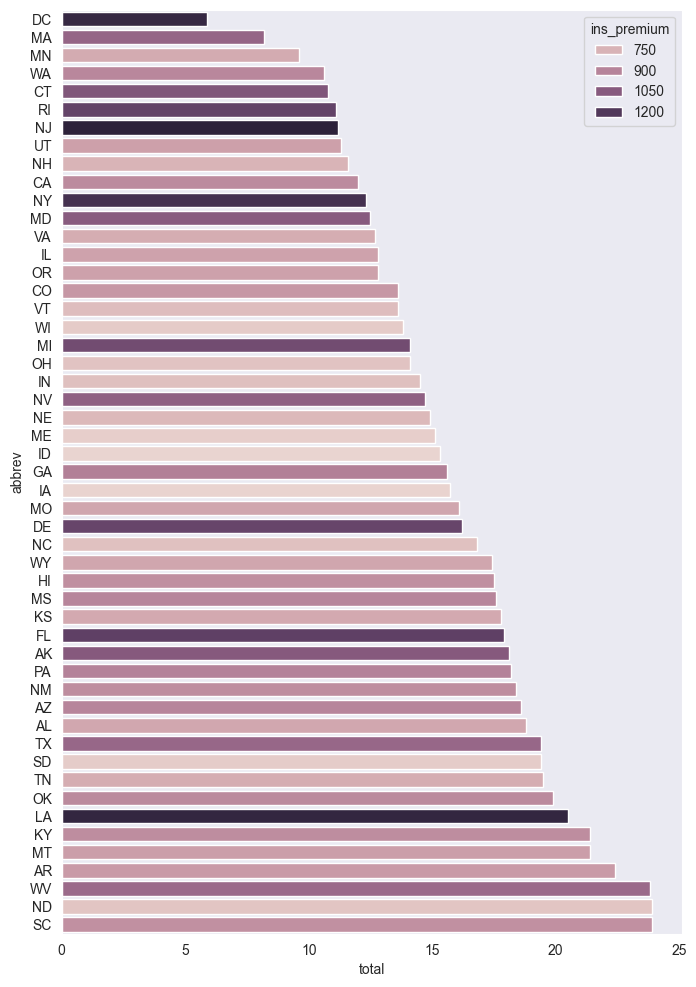

In [ ]:
plt.figure(figsize=(8, 12))
sns.set_style("dark")
sns.barplot(data=df.sort_values("total"), x='total', y='abbrev',hue = 'ins_premium')

We finally explore relation between drivers not bring distracted and drinking accidents using heat map, this graph will show if drinking actually affects proper human response time and ability to drive well under the influence.

Since using a heat map would creat a very large grid with alot of empty values as the speeding and not distracted values are not exact, ex:6,321
We will use a kdeplot to show the same phenomenom but in a more elegenat way.

The plot below shows theres a postive correlation between  drinking and speeding crashess, the values clustring near the right edge mean that the trend of drinking and still making a crash while not being distracted is fairly large.

<Axes: xlabel='alcohol', ylabel='not_distracted'>

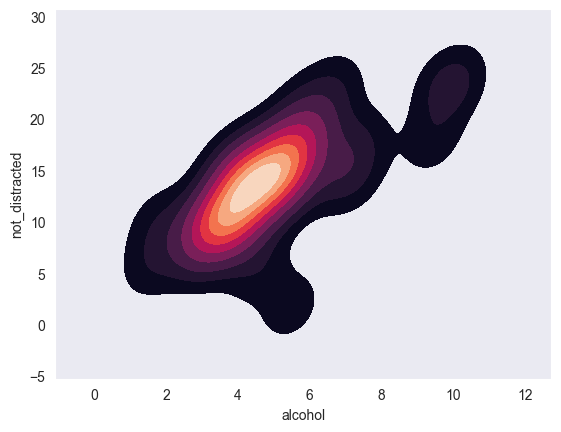

In [78]:


sns.kdeplot(data=df, x="alcohol", y="not_distracted", fill=True, cmap="rocket")